# Øvelse 8

I denne øvingsoppgaven skal dere finne ut av hvor mange mennesker som bor innenfor en 3000-meter radius fra Ås videregående skole. Noen av kodecellene er allerede utfylt, men dere skal selv fylle ut resten. Dere kan løse oppgaven litt som dere vil, så lenge dere bruker variabelnavenen som blir beskrevet her.

Husk å lagre og laste ned denne Notebook-en når du har fylt den ut og last den opp på Canvas som svar på øvingsoppgaven

Importer de nødvendige bibliotekene:

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

## Lese inn befolkningsdata

I mappen `data` ligger det to filer, et befolkningsgrid og en fil for Ås VGS. Stiene er henholdsvis:
1. `data/befolkning_viken_2018.gml`
2. `data/aas_vgs.gml`

Vi skal nå lese inn befolkningsgriden:
1. Bruk `read_file`-funksjonen til geopandas og skriv inn stien til befolkningsdataene, og lagre det i en variable med navn `befolkning`
2. Gjør deg kjent med datasettet ved å bruke `.head()`-funksjonen

In [ ]:
befolkning = gpd.read_file('https://github.com/haavardaagesen/gmgi210/raw/refs/heads/main/data/befolkning_viken_2018.gml')
befolkning.head()

,gml_id,lokalId,navnerom,versjonId,oppdateringsdato,datauttaksdato,opphav,ssbid1000M,popTot,popAve,popFem,popMal,statistikkÅr,geometry
0,id0b1beeca-9e3b-404d-98bb-5ffa2172d8c8,0224ac3d-f655-4e8a-a2dc-cfcbbb5ad765,http://data.geonorge.no/sosi/befolkning/befolk...,20200101,2018-01-01T00:00:00,2021-03-23T11:12:39,SSB,21200006742000,3,0.0,1,2,2018,"POLYGON ((121000.001 6741999.995, 120000.001 6..."
1,id8e8f920f-faf8-4526-ac5a-b76fe57e52f0,feb68e8f-bbac-47ee-8fae-3c56666ca2d9,http://data.geonorge.no/sosi/befolkning/befolk...,20200101,2018-01-01T00:00:00,2021-03-23T11:12:39,SSB,21230006741000,2,0.0,1,1,2018,"POLYGON ((124000.001 6740999.996, 123000.001 6..."
2,id0b34d217-1112-4da7-bd3f-069ce9071499,c9830aec-6f6b-489f-91aa-486dd50e6f6b,http://data.geonorge.no/sosi/befolkning/befolk...,20200101,2018-01-01T00:00:00,2021-03-23T11:12:39,SSB,21240006741000,7,34.4,3,4,2018,"POLYGON ((125000.001 6740999.996, 124000.001 6..."
3,idd2b24732-91e5-4a36-aaca-fc33aa3ef259,4c8a1c83-d6d6-419c-90cd-76f727fbc399,http://data.geonorge.no/sosi/befolkning/befolk...,20200101,2018-01-01T00:00:00,2021-03-23T11:12:39,SSB,21250006741000,6,71.5,2,4,2018,"POLYGON ((126000.001 6740999.996, 125000.001 6..."
4,id0d4302b1-5ad2-4684-bc08-0daefe08ff84,0196fa77-9092-414e-9f83-3efd12f35602,http://data.geonorge.no/sosi/befolkning/befolk...,20200101,2018-01-01T00:00:00,2021-03-23T11:12:42,SSB,21410006740000,3,0.0,2,1,2018,"POLYGON ((142000.001 6739999.997, 141000.001 6..."


Nå skal du ha en GeoDataFrame med befolkningstallet for hver grid-celle. Befolkningstallet vi skal bruke senere ligger i kolonnen `popTot`.
Bruk `.plot()`-funksjonen til å lage et raskt kart over griden.

<AxesSubplot: >

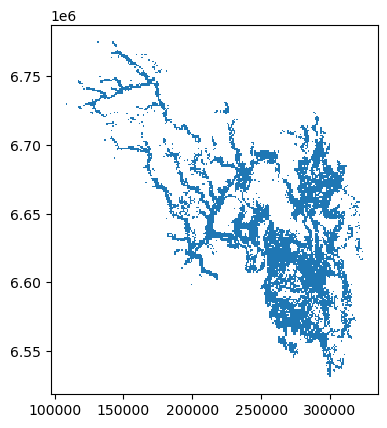

In [3]:
befolkning.plot()

## Lese inn VGS-data

Les inn filen for Ås VGS på samme måte som med befolkningsdataene. Lagre det i en variabel som heter `vgs` og inspiser dataene med `.head)`

In [ ]:
vgs = gpd.read_file('https://github.com/haavardaagesen/gmgi210/raw/refs/heads/main/data/aas_vgs.gml')
vgs.head()

,gml_id,lokalId,navnerom,versjonId,kommunenummer,datauttaksdato,oppdateringsdato,målemetode,skolenavn,lavesteTrinn,...,poststed,postadresse|Postadresse|adressenavn,postadresse|Postadresse|postnummer,postadresse|Postadresse|poststed,fylkesnummer,kontaktinformasjon|Kontaktinformasjon|epostadresse,kontaktinformasjon|Kontaktinformasjon|telefonnummer,webside,iDrift,geometry
0,id24261fa6-3c0e-427b-beac-2d1fed1dd249,dcd24111-09d2-4024-983a-19965138a1ee,https://data.geonorge.no/sosi/befolkning/vider...,20190301,3021,2022-09-19T20:00:56,2022-09-13T10:54:35,63,Ås videregående skole,11,...,ÅS,POSTBOKS 10,1435,Ås,30,asvgs@viken.no,64975700,viken.no/aas-vgs,Ja,POINT (263222.330 6621411.969)


Du skal nå ha en GeoDataFrame med bare ett punkt. Sjekk om dette stemmer ved å plotte en raskt kart.

<AxesSubplot: >

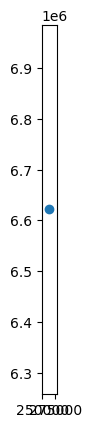

In [5]:
vgs.plot()

## Lage en buffer

For å se hvor mange som bor innenfor en viss radius av Ås VGS, skal vi nå buffre 3000 meter rundt skolen:

For å lage en buffer, bruker vi den innebydge funksjonen `.buffer()` og så angi hvor mange meter vi ønsker å buffre i funksjonen. `.buffer()`-funksjonen kan vi bruke direkte på en GeoDataFrame, for eksempel ved `vgs.buffer(antallMeter)`.
Lagre resultatet i en ny variabel som du kaller `skole_buffer`.

For å sjekke om resultatet ser riktig ut, kan du plotte den nye bufferen og se om du har en helt rund sirkel.

In [6]:
skole_buffer = vgs.buffer(3000)

## Lage en GeoDataFrame fra bufferen

For å koble den nye bufferen vår sammen med befolkningsdatane, må vi først gjøre bufferen om til en GeoDataFrame:

1. Bruk Geopandas sin funksjon for å lage en GeoDataFrame: `gpd.GeoDataFrame()` og gi den parametrene `skole_buffer` og `geometry=skole_buffer`
2. Lagre den nye GeoDataFramen i en variabel som heter `buffer_gdf`.
3. For å sjekke at alt er riktig kan du printe ut den nye `buffer_gdf` og bruke `type()` for å se at alt stemmer

In [7]:
buffer_gdf = gpd.GeoDataFrame(skole_buffer, geometry=skole_buffer)
print(type(buffer_gdf))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [8]:
print(len(buffer_gdf))

1


In [9]:
test = gpd.GeoDataFrame(geometry=skole_buffer)
print(buffer_gdf.head)
print(test.head)
print(test.shape)

<bound method NDFrame.head of                                                    0  \
0  POLYGON ((266222.330 6621411.969, 266207.884 6...   

                                            geometry  
0  POLYGON ((266222.330 6621411.969, 266207.884 6...  >
<bound method NDFrame.head of                                             geometry
0  POLYGON ((266222.330 6621411.969, 266207.884 6...>
(1, 1)


## Punkt/Grid-celle i polygon-analyse

Vi skal nå finne ut hvilke av grid-cellene som befinner seg innenfor bufferen vår og hvor mange som bor i disse grid-cellene.

Først kan vi lage en maske som vi bruker til å velge ut grid-cellene som faller innenfor bufferen. Se også notebooken fra forelesningen for å se hvordan vi gjorde det da.

1. Bruk `within()`-funksjonen på befolkningsdatasettet, og angi buffer-GeoDataFramen vår som parameter. Husk å angi geometrien, f.eks. ved hjelp av `at[0, 'geometry']`
2. Lagre resultatet som variablen `pip_mask`
3. Bruk denne masken til å filtrere beolkningsdataene våre. `.loc[]` er en nyttig funksjon for å få til det.
4. Lagre dette resultatet i variablen `pip_data`

In [10]:
pip_mask = befolkning.within(test.at[0, 'geometry'])

In [11]:
print(len(pip_mask))

8248


In [12]:
pip_data = befolkning.loc[pip_mask]

Nå skal vi sitte igjen med kun de grid-cellene som er innenfor 3000 meter fra Ås VGS. Vi kan sjekke hvor mange celler dette er ved å ta en titt på `pip_data`. Bruk enten `.shape`- eller `len()`-funksjonen til å finne ut hvor mange celler/rader vi har i `pip_data`.

In [13]:
print(len(pip_data))

18


Nå vet vi hvor mange grid-celler dette gjelder, men hvor mange mennesker er det som bor i disse cellene?

La oss finne ut av det. Befolkningstallet for hver celle er lagret i `popTot`-kolonnene. For å finne summen av alle cellene, kan vi bruke `.sum()`-funksjonen på en enkelt kolonne i GeoDataFramen. Velg riktig kolonne i `pip_data` og bruk `.sum()` og lagre resultatet i en variable med navn `antall`. 

Print ut antallet. 

In [14]:
antall = pip_data['popTot'].sum()
print(antall)

10259


## Visualisering

Vi kan også vise utvalget av grid-celler på et interaktivt kart. Bruk `.explore()`-funksjonen til å lage et kart. Hvis du i tillegg vil visualiere hvor mange som bor i de ulike cellene, kan du gi kolonnen du ønsker å visualisere som et parameter til `column=NavnPåKolonne` når du lager kartet. 

In [15]:
pip_data.explore(column='popTot')

# Før du leverer:

Husk å lagre, laste ned og endre navn på filen, og så laste den opp på Canvas.

Bruk cellen under til å kommentere om det var noe du ikke fikk til eller om noe var veldig vanskelig: